In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import joblib

warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("dogecoin.csv")
print(df.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0   11/9/2017  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0
1  11/10/2017  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0
2  11/11/2017  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0
3  11/12/2017  0.001189  0.001210  0.001002  0.001038   0.001038  3288960.0
4  11/13/2017  0.001046  0.001212  0.001019  0.001211   0.001211  2481270.0


Exploratory Data Analysis (EDA)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1761 non-null   str    
 1   Open       1760 non-null   float64
 2   High       1760 non-null   float64
 3   Low        1760 non-null   float64
 4   Close      1760 non-null   float64
 5   Adj Close  1760 non-null   float64
 6   Volume     1760 non-null   float64
dtypes: float64(6), str(1)
memory usage: 111.8 KB


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


In [7]:
df.isnull().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [8]:
#  Dropping the null value as it is very less in number and will not affect the model performance
df.dropna(inplace = True)
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [9]:
# Visuasilizing the data to get a better understanding 
# for cols in df.columns:
#     plt.figure(figsize = (10,5))
#     sns.histplot(df[cols],kde = True, bins =100)
#     plt.show()

In [10]:
df.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
dtype: object

In [11]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

In [12]:
df.corr(numeric_only = True, method = "pearson")

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


<Axes: >

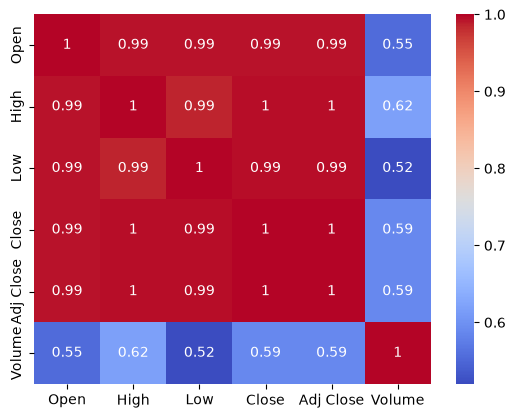

In [13]:
# Heatmap generation to visualize the correlation between the features 
sns.heatmap(df.corr(numeric_only = True , method = "pearson"),annot = True , cmap = "coolwarm")

In [14]:
# Breaking the dates into year month day
df = df.sort_values('Date')
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0,2017,11,9
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0,2017,11,10
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0,2017,11,11
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0,2017,11,12
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0,2017,11,13


In [15]:
df['Target'] = df['Close'].shift(-1)
print(df.head())

        Date      Open      High       Low     Close  Adj Close     Volume  \
0 2017-11-09  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0   
1 2017-11-10  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0   
2 2017-11-11  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0   
3 2017-11-12  0.001189  0.001210  0.001002  0.001038   0.001038  3288960.0   
4 2017-11-13  0.001046  0.001212  0.001019  0.001211   0.001211  2481270.0   

   Year  Month  Day    Target  
0  2017     11    9  0.001163  
1  2017     11   10  0.001201  
2  2017     11   11  0.001038  
3  2017     11   12  0.001211  
4  2017     11   13  0.001184  


In [16]:
# Model selection and training
df = df.dropna().reset_index(drop=True)
X = df.drop(['Date','Target'], axis = 1)
y = df['Target']


print(X.head())
print(y.head())

# Standard Scalarisation of the data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

       Open      High       Low     Close  Adj Close     Volume  Year  Month  \
0  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0  2017     11   
1  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0  2017     11   
2  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0  2017     11   
3  0.001189  0.001210  0.001002  0.001038   0.001038  3288960.0  2017     11   
4  0.001046  0.001212  0.001019  0.001211   0.001211  2481270.0  2017     11   

   Day  
0    9  
1   10  
2   11  
3   12  
4   13  
0    0.001163
1    0.001201
2    0.001038
3    0.001211
4    0.001184
Name: Target, dtype: float64
[[-0.5760236  -0.56509295 -0.58638268 ... -1.95028405  1.33112988
  -0.76898394]
 [-0.5739116  -0.56494636 -0.58698036 ... -1.95028405  1.33112988
  -0.65525914]
 [-0.57662563 -0.56654047 -0.5868096  ... -1.95028405  1.33112988
  -0.54153434]
 ...
 [ 0.01935563  0.00217268  0.05267777 ...  1.5660645   0.46252936
   1.73296162]
 [ 0.01740153 -0.0056513   0.04345639

In [17]:
# Using unscaled features for random forest classifier as it is not affected by the scale of the features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(X_train,y_train)
model

y_pred = model.predict(X_test)
print(f"R2 Score : {r2_score(y_test,y_pred)}")
print(f"Mean Absolute Error : {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Squared Error : {mean_squared_error(y_test,y_pred)}")
print(f"Root Mean Squared Error : {np.sqrt(mean_squared_error(y_test,y_pred))}")
print("\n")

R2 Score : 0.9699205784541685
Mean Absolute Error : 0.004676465397727265
Mean Squared Error : 0.00033609317775879286
Root Mean Squared Error : 0.018332844235382378




In [18]:
# Using scaled features for other models as they are affected by the scale of the features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)
models = {
    # "RandomForestRegressor" : RandomForestRegressor(n_estimators = 100, random_state = 42),
    "LinearRegression" : LinearRegression(),
    "KNN" : KNeighborsRegressor(n_neighbors = 5),
    "SVM" : SVR(kernel = 'rbf', C = 1, gamma = 0.001, epsilon=0.001)
}

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    print(f"Model : {name}")
    print(f"R2 Score : {r2_score(y_test,y_pred)}")
    print(f"Mean Absolute Error : {mean_absolute_error(y_test,y_pred)}")
    print(f"Mean Squared Error : {mean_squared_error(y_test,y_pred)}")
    print(f"Root Mean Squared Error : {np.sqrt(mean_squared_error(y_test,y_pred))}")
    print("\n")

Model : LinearRegression
R2 Score : 0.9673287285003916
Mean Absolute Error : 0.005009562128428346
Mean Squared Error : 0.0003650532788003489
Root Mean Squared Error : 0.019106367493596184


Model : KNN
R2 Score : 0.9573290175813438
Mean Absolute Error : 0.005170247159090909
Mean Squared Error : 0.0004767853017826137
Root Mean Squared Error : 0.021835413936598814


Model : SVM
R2 Score : 0.966710962389957
Mean Absolute Error : 0.00453221660907693
Mean Squared Error : 0.00037195590406697144
Root Mean Squared Error : 0.019286158354295743




In [19]:
# Applying grid search cv for better performance of  svm model
svm = SVR(kernel='rbf')
param_grid = {
    'C': [1, 10, 50, 100, 200, 500],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'epsilon': [0.001, 0.01, 0.05, 0.1, 0.2]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV R²:")
print(grid_search.best_score_)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best Parameters:
{'C': 1, 'epsilon': 0.001, 'gamma': 0.001}

Best CV R²:
0.9877940644419414


In [20]:
joblib.dump(models["LinearRegression"],"LinearRegression_model.pkl")

['LinearRegression_model.pkl']

In [21]:
joblib.dump(scaler,"scalar.pkl")
joblib.dump(X.columns.tolist(),"columns.pkl")

['columns.pkl']